
========== TRANSACTION DATA ==========
  Transaction_ID        Date Account_ID Payment_Method     Category  Amount
0           T001  2026-07-01     ACC101            UPI      Grocery     637
1           T002  2026-07-01     ACC102           Card     Shopping     774
2           T003  2026-07-01     ACC103  Bank Transfer         Food     911
3           T004  2026-07-02     ACC104            UPI  Electronics    1048
4           T005  2026-07-02     ACC105           Card       Travel    1185

Dataset Shape: (91, 6)

Columns:
['Transaction_ID', 'Date', 'Account_ID', 'Payment_Method', 'Category', 'Amount']

========== DATA CLEANING ==========

Missing Values:
Transaction_ID    0
Date              0
Account_ID        0
Payment_Method    0
Category          0
Amount            0
dtype: int64

Duplicate Transactions: 1

Duplicate Records:
   Transaction_ID        Date Account_ID Payment_Method Category  Amount
24           T025  2026-07-09     ACC105            UPI  Grocery    3925
90       

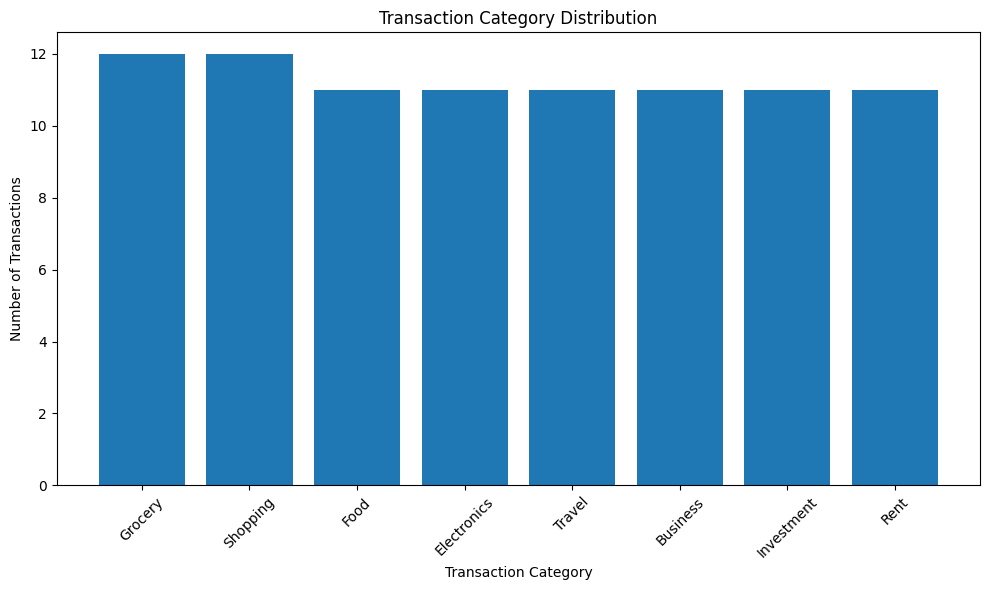

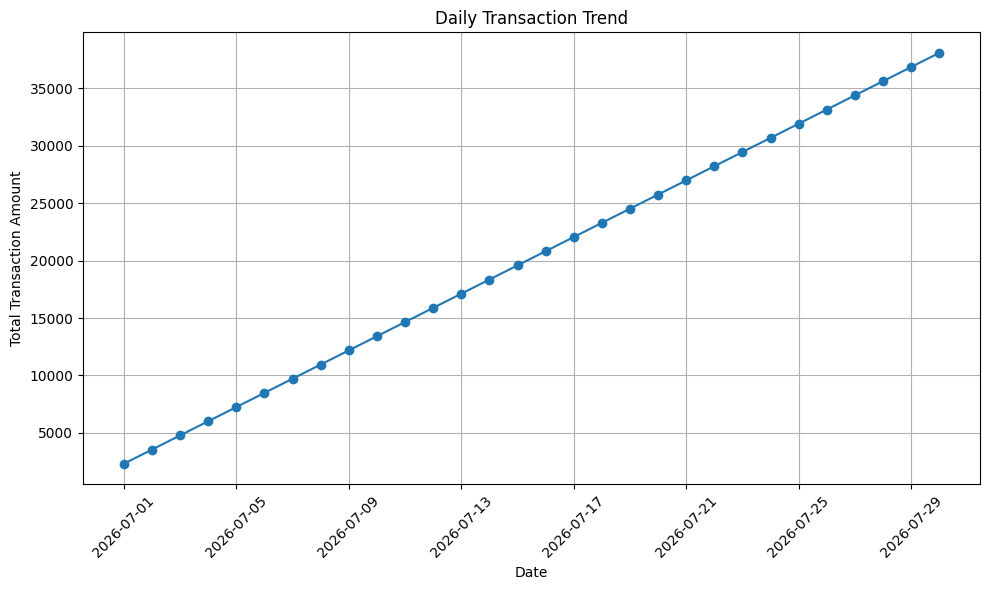


========== TOP 10 TRANSACTIONS ==========
   Transaction_ID Account_ID     Category  Amount
89           T090     ACC110     Shopping   12830
88           T089     ACC109      Grocery   12693
87           T088     ACC108         Rent   12556
86           T087     ACC107   Investment   12419
85           T086     ACC106     Business   12282
84           T085     ACC105       Travel   12145
83           T084     ACC104  Electronics   12008
82           T083     ACC103         Food   11871
81           T082     ACC102     Shopping   11734
80           T081     ACC101      Grocery   11597


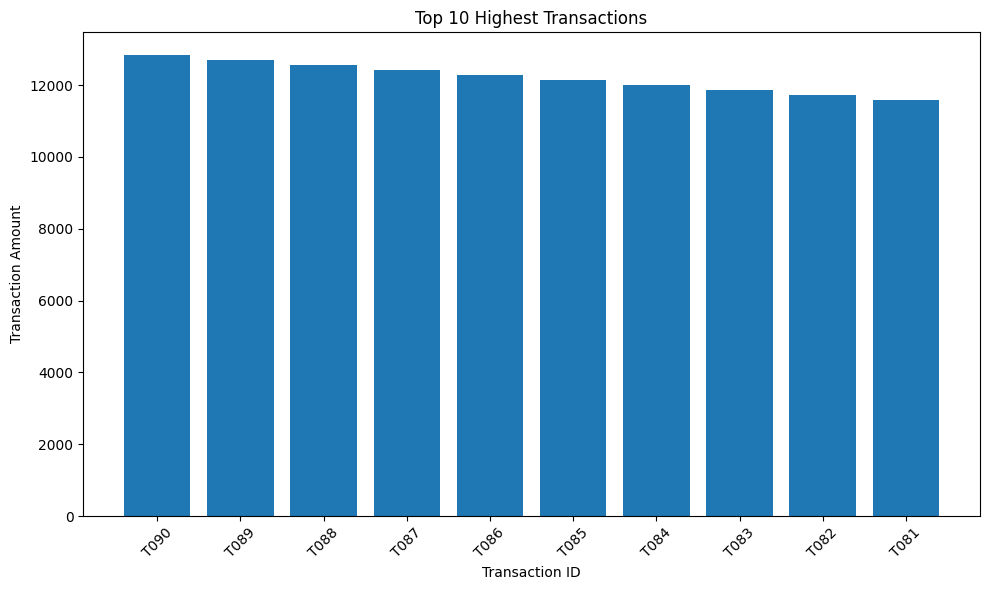


========== PROJECT SUMMARY ==========
Total Transactions: 90
Duplicate Transactions: 1
High-Value Transactions: 0
Suspicious Accounts: 10
Suspicious Transactions: 22
Highest Transaction: ₹12,830.00

🎉 FRAUD DETECTION PROJECT COMPLETED!


In [2]:
import pandas as pd
import matplotlib.pyplot as plt


# ==========================================
# 1. READ TRANSACTION DATA
# ==========================================

df = pd.read_csv("transaction_data.csv")

print("\n========== TRANSACTION DATA ==========")
print(df.head())

print("\nDataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())


# ==========================================
# 2. DATA CLEANING
# ==========================================

print("\n========== DATA CLEANING ==========")

# Check missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Check duplicate transactions
duplicate_count = df.duplicated().sum()

print("\nDuplicate Transactions:", duplicate_count)

# Display duplicate transactions
duplicates = df[df.duplicated(keep=False)]

if len(duplicates) > 0:
    print("\nDuplicate Records:")
    print(duplicates)

# Remove duplicates
df = df.drop_duplicates()

# Remove missing values
df = df.dropna()

# Convert Date
df["Date"] = pd.to_datetime(df["Date"])

print("\nData after cleaning:")
print(df.head())

print("\nFinal Dataset Shape:", df.shape)


# ==========================================
# 3. HIGH-VALUE TRANSACTIONS
# ==========================================

print("\n========== HIGH-VALUE TRANSACTIONS ==========")

# Set threshold
threshold = 100000

high_value = df[df["Amount"] > threshold]

print(
    f"\nTransactions above ₹{threshold:,}:"
)

print(
    high_value[
        [
            "Transaction_ID",
            "Account_ID",
            "Category",
            "Amount"
        ]
    ]
)

print(
    "\nNumber of high-value transactions:",
    len(high_value)
)


# ==========================================
# 4. FREQUENT / SUSPICIOUS ACCOUNTS
# ==========================================

print("\n========== FREQUENT ACCOUNTS ==========")

account_frequency = (
    df.groupby("Account_ID")
    .size()
    .sort_values(ascending=False)
)

print(account_frequency)

# Consider accounts having 8 or more transactions
frequency_threshold = 8

suspicious_accounts = account_frequency[
    account_frequency >= frequency_threshold
]

print(
    f"\nAccounts with {frequency_threshold}+ transactions:"
)

print(suspicious_accounts)


# ==========================================
# 5. CREATE RISK SCORE
# ==========================================

print("\n========== RISK SCORE ==========")

def calculate_risk(row):

    score = 0

    # High-value transaction
    if row["Amount"] > 100000:
        score += 50

    # Medium-high transaction
    elif row["Amount"] > 50000:
        score += 25

    # Frequent account
    if row["Account_ID"] in suspicious_accounts.index:
        score += 30

    # Business / Investment transactions
    if row["Category"] in ["Business", "Investment"]:
        score += 10

    return score


df["Risk_Score"] = df.apply(
    calculate_risk,
    axis=1
)


# Risk level
def risk_level(score):

    if score >= 70:
        return "High"

    elif score >= 40:
        return "Medium"

    else:
        return "Low"


df["Risk_Level"] = df["Risk_Score"].apply(
    risk_level
)

print(
    df[
        [
            "Transaction_ID",
            "Account_ID",
            "Amount",
            "Risk_Score",
            "Risk_Level"
        ]
    ].head(20)
)


# ==========================================
# 6. SUSPICIOUS TRANSACTIONS
# ==========================================

suspicious_transactions = df[
    (df["Risk_Score"] >= 40)
]

print("\n========== SUSPICIOUS TRANSACTIONS ==========")

print(
    suspicious_transactions[
        [
            "Transaction_ID",
            "Date",
            "Account_ID",
            "Category",
            "Amount",
            "Risk_Score",
            "Risk_Level"
        ]
    ]
)


# ==========================================
# 7. EXPORT SUSPICIOUS TRANSACTIONS
# ==========================================

suspicious_transactions.to_csv(
    "suspicious_transactions.csv",
    index=False
)

print(
    "\n✅ Suspicious transactions exported!"
)

print(
    "File: suspicious_transactions.csv"
)


# ==========================================
# 8. TRANSACTION CATEGORY CHART
# ==========================================

category_count = df["Category"].value_counts()

plt.figure(figsize=(10, 6))

plt.bar(
    category_count.index,
    category_count.values
)

plt.title("Transaction Category Distribution")
plt.xlabel("Transaction Category")
plt.ylabel("Number of Transactions")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "transaction_category_chart.png"
)

plt.show()


# ==========================================
# 9. DAILY TRANSACTION TREND
# ==========================================

daily_transactions = (
    df.groupby("Date")["Amount"]
    .sum()
)

plt.figure(figsize=(10, 6))

plt.plot(
    daily_transactions.index,
    daily_transactions.values,
    marker="o"
)

plt.title("Daily Transaction Trend")
plt.xlabel("Date")
plt.ylabel("Total Transaction Amount")

plt.xticks(rotation=45)

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "daily_transaction_trend.png"
)

plt.show()


# ==========================================
# 10. TOP 10 HIGHEST TRANSACTIONS
# ==========================================

top_10 = (
    df.sort_values(
        by="Amount",
        ascending=False
    )
    .head(10)
)

print("\n========== TOP 10 TRANSACTIONS ==========")

print(
    top_10[
        [
            "Transaction_ID",
            "Account_ID",
            "Category",
            "Amount"
        ]
    ]
)


plt.figure(figsize=(10, 6))

plt.bar(
    top_10["Transaction_ID"],
    top_10["Amount"]
)

plt.title("Top 10 Highest Transactions")

plt.xlabel("Transaction ID")
plt.ylabel("Transaction Amount")

plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "top_10_transactions.png"
)

plt.show()


# ==========================================
# 11. PROJECT SUMMARY
# ==========================================

print("\n========== PROJECT SUMMARY ==========")

print(
    "Total Transactions:",
    len(df)
)

print(
    "Duplicate Transactions:",
    duplicate_count
)

print(
    "High-Value Transactions:",
    len(high_value)
)

print(
    "Suspicious Accounts:",
    len(suspicious_accounts)
)

print(
    "Suspicious Transactions:",
    len(suspicious_transactions)
)

print(
    "Highest Transaction:",
    f"₹{df['Amount'].max():,.2f}"
)

print("\n🎉 FRAUD DETECTION PROJECT COMPLETED!")